In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from io import StringIO

# Load all 3 NREL files from S3
bucket = "gridsense-ai-data-team1"
s3 = boto3.client("s3")

nrel_files = [
    "1545408_30.30_-97.71_2022_ff25f18395b8033aeb23ca6f1c973bf4.csv",
    "1545408_30.30_-97.71_2023_fa0d07fb0da2452c557f67cfe8cd69cd.csv",
    "1545408_30.30_-97.71_2024_34550f7445646d50c7e4e3be9f680d03.csv",
]

dfs = []
for file in nrel_files:
    print(f"Loading {file}...")
    obj = s3.get_object(Bucket=bucket, Key=file)
    df = pd.read_csv(obj["Body"], skiprows=2)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(f"\nCombined shape: {data.shape}")
print(data.head())

Loading 1545408_30.30_-97.71_2022_ff25f18395b8033aeb23ca6f1c973bf4.csv...
Loading 1545408_30.30_-97.71_2023_fa0d07fb0da2452c557f67cfe8cd69cd.csv...
Loading 1545408_30.30_-97.71_2024_34550f7445646d50c7e4e3be9f680d03.csv...

Combined shape: (26280, 11)
   Year  Month  Day  Hour  Minute  GHI  DNI  DHI  Wind Speed  Temperature  \
0  2022      1    1     0      30    0    0    0         4.8         21.1   
1  2022      1    1     1      30    0    0    0         5.2         21.2   
2  2022      1    1     2      30    0    0    0         5.2         21.2   
3  2022      1    1     3      30    0    0    0         5.1         21.2   
4  2022      1    1     4      30    0    0    0         5.1         21.2   

   Cloud Type  
0           8  
1           1  
2           7  
3           7  
4           7  


In [4]:
# Data types, missing values, and summary stats
print("Data Types:")
print(data.dtypes)
print("\nMissing Values:")
print(data.isnull().sum())
print("\nDate Range:")
print("Start: Year", data['Year'].min(), "Month", data['Month'].min())
print("End: Year", data['Year'].max(), "Month", data['Month'].max())
print("\nSummary Statistics:")
print(data.describe())

Data Types:
Year             int64
Month            int64
Day              int64
Hour             int64
Minute           int64
GHI              int64
DNI              int64
DHI              int64
Wind Speed     float64
Temperature    float64
Cloud Type       int64
dtype: object

Missing Values:
Year           0
Month          0
Day            0
Hour           0
Minute         0
GHI            0
DNI            0
DHI            0
Wind Speed     0
Temperature    0
Cloud Type     0
dtype: int64

Date Range:
Start: Year 2022 Month 1
End: Year 2024 Month 12

Summary Statistics:
               Year         Month           Day          Hour   Minute  \
count  26280.000000  26280.000000  26280.000000  26280.000000  26280.0   
mean    2023.000000      6.526027     15.720548     11.500000     30.0   
std        0.816512      3.447917      8.796414      6.922318      0.0   
min     2022.000000      1.000000      1.000000      0.000000     30.0   
25%     2022.000000      4.000000      8.000000    

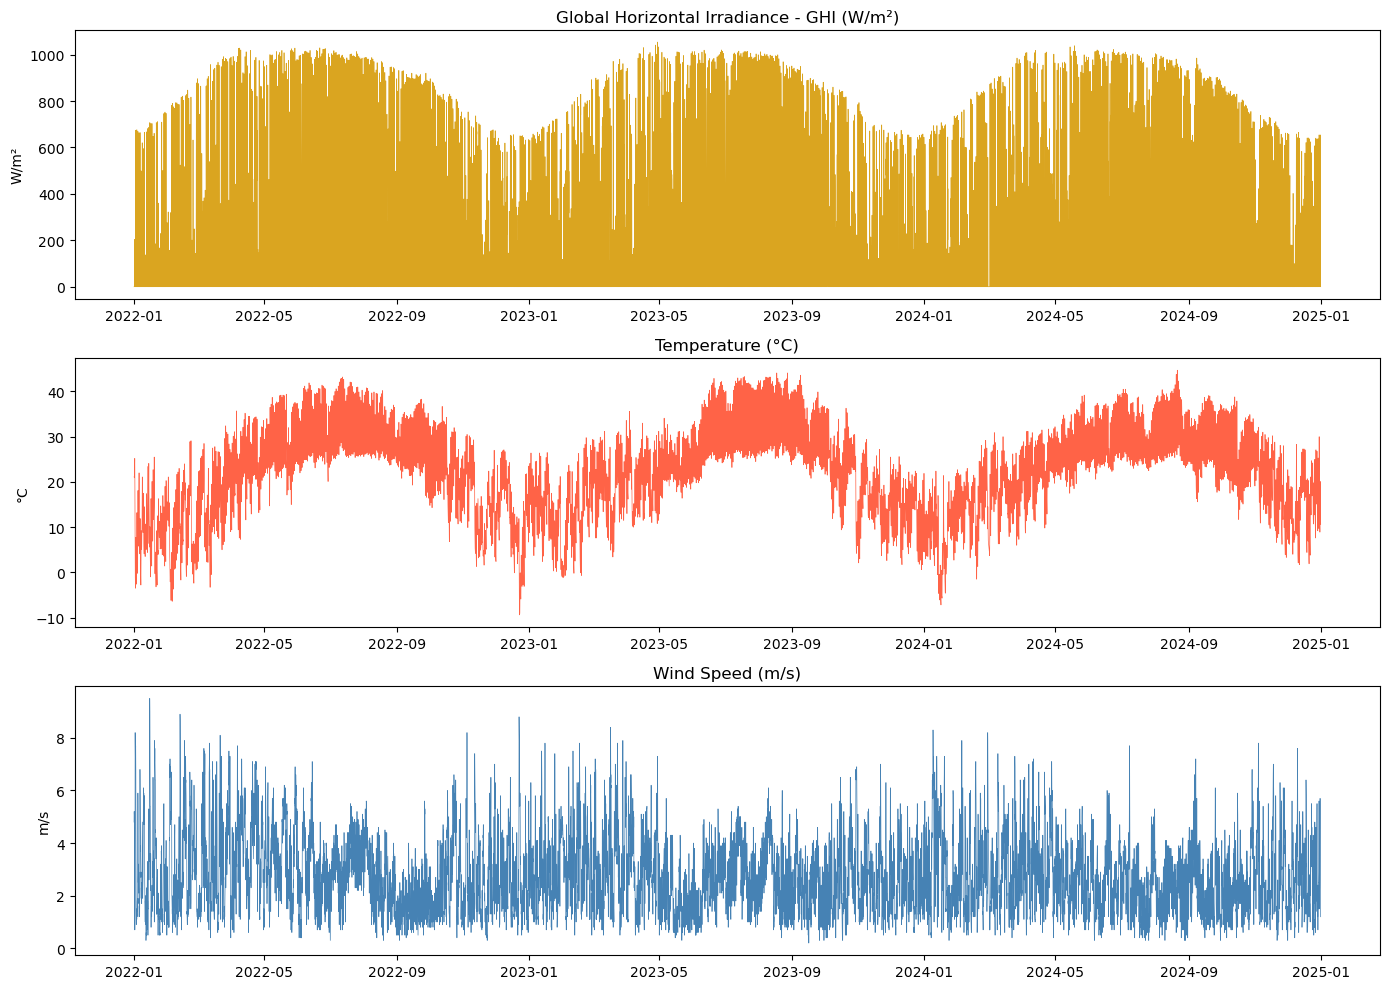

Plot saved.


In [5]:
# Create datetime column for plotting
data['datetime'] = pd.to_datetime(data[['Year', 'Month', 'Day', 'Hour']].rename(columns={
    'Year': 'year', 'Month': 'month', 'Day': 'day', 'Hour': 'hour'
}))

# Plot GHI and Temperature over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(data['datetime'], data['GHI'], linewidth=0.5, color='goldenrod')
axes[0].set_title('Global Horizontal Irradiance - GHI (W/m²)')
axes[0].set_ylabel('W/m²')

axes[1].plot(data['datetime'], data['Temperature'], linewidth=0.5, color='tomato')
axes[1].set_title('Temperature (°C)')
axes[1].set_ylabel('°C')

axes[2].plot(data['datetime'], data['Wind Speed'], linewidth=0.5, color='steelblue')
axes[2].set_title('Wind Speed (m/s)')
axes[2].set_ylabel('m/s')

plt.tight_layout()
plt.savefig('nrel_variables.png')
plt.show()
print("Plot saved.")

In [7]:
# Check duplicate rows
duplicates = data.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Cloud type distribution
print("\nCloud Type Distribution:")
print(data['Cloud Type'].value_counts().sort_index())
print("\nCloud Type Meanings:")
cloud_types = {
    0: "Clear",
    1: "Probably Clear",
    2: "Fog",
    3: "Water",
    4: "Super-Cooled Water",
    5: "Mixed",
    6: "Opaque Ice",
    7: "Cirrus",
    8: "Overlapping",
    9: "Overshooting"
}
for k, v in cloud_types.items():
    print(f"  {k}: {v}")

Duplicate rows: 0

Cloud Type Distribution:
Cloud Type
0    14315
1     1663
2      256
3     3033
4      566
5      242
6      789
7     3690
8     1466
9      260
Name: count, dtype: int64

Cloud Type Meanings:
  0: Clear
  1: Probably Clear
  2: Fog
  3: Water
  4: Super-Cooled Water
  5: Mixed
  6: Opaque Ice
  7: Cirrus
  8: Overlapping
  9: Overshooting


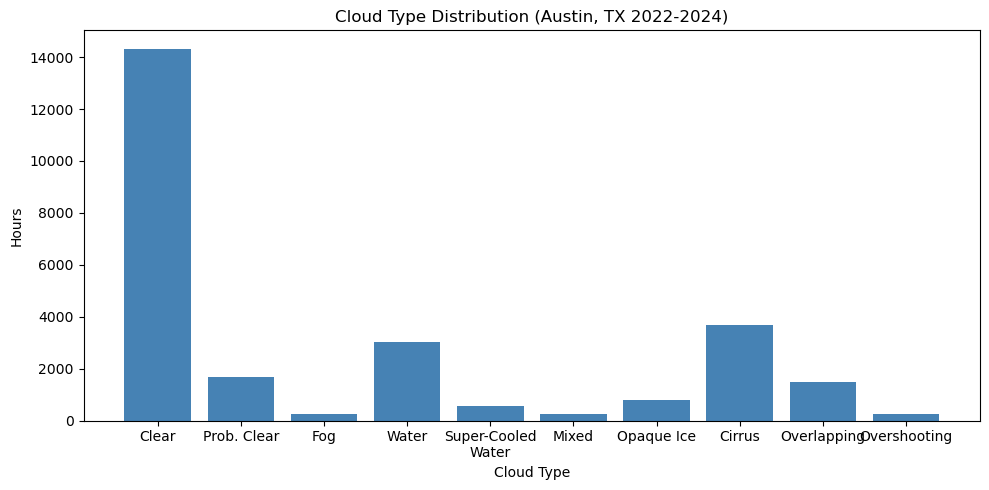


Correlation Matrix:
              GHI   DNI   DHI  Wind Speed  Temperature
GHI          1.00  0.88  0.64        0.23         0.52
DNI          0.88  1.00  0.35        0.18         0.40
DHI          0.64  0.35  1.00        0.26         0.42
Wind Speed   0.23  0.18  0.26        1.00         0.08
Temperature  0.52  0.40  0.42        0.08         1.00


In [8]:
# Cloud type distribution bar chart
plt.figure(figsize=(10, 5))
cloud_labels = ['Clear', 'Prob. Clear', 'Fog', 'Water', 'Super-Cooled\nWater', 
                'Mixed', 'Opaque Ice', 'Cirrus', 'Overlapping', 'Overshooting']
counts = data['Cloud Type'].value_counts().sort_index()
plt.bar(cloud_labels, counts.values, color='steelblue')
plt.title('Cloud Type Distribution (Austin, TX 2022-2024)')
plt.xlabel('Cloud Type')
plt.ylabel('Hours')
plt.tight_layout()
plt.savefig('nrel_cloud_distribution.png')
plt.show()

# Correlation between solar variables
print("\nCorrelation Matrix:")
print(data[['GHI', 'DNI', 'DHI', 'Wind Speed', 'Temperature']].corr().round(2))

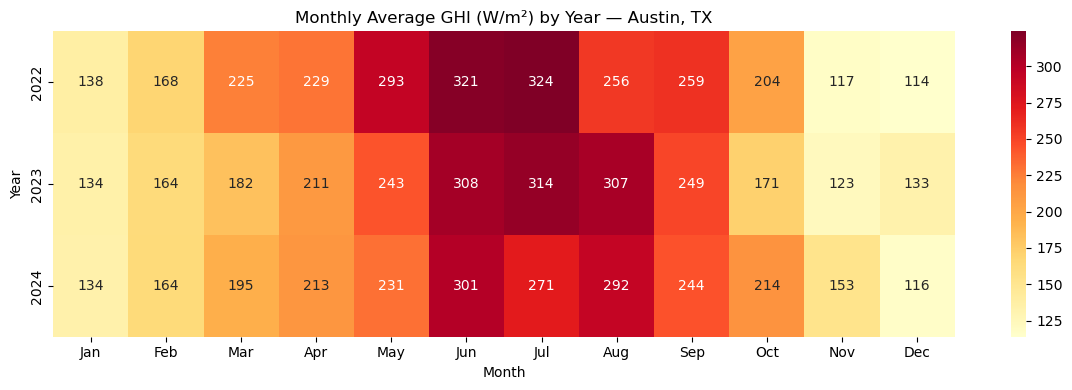

Plot saved.


In [9]:
# Monthly average GHI heatmap by year
data['Year'] = data['Year'].astype(int)
data['Month'] = data['Month'].astype(int)

monthly_ghi = data.groupby(['Year', 'Month'])['GHI'].mean().unstack()

plt.figure(figsize=(12, 4))
sns.heatmap(monthly_ghi, annot=True, fmt='.0f', cmap='YlOrRd', 
            xticklabels=['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'],
            yticklabels=['2022','2023','2024'])
plt.title('Monthly Average GHI (W/m²) by Year — Austin, TX')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('nrel_ghi_heatmap.png')
plt.show()
print("Plot saved.")

## NREL Data Exploration Summary

**Dataset:** NREL NSRDB GOES CONUS v4.0.0 (Austin, TX — ERCOT Region)  
**Shape:** 26,280 rows × 11 columns  
**Date Range:** January 1, 2022 to December 31, 2024  
**Location:** 30.30°N, -97.71°W (Austin, TX)  

### Key Findings
- Zero null values and zero duplicate rows — perfectly clean dataset
- GHI peaks at 1,054 W/m² in summer — strong solar generation potential for Texas
- Temperature ranges from -9.4°C to 44.7°C — captures both winter and summer grid stress conditions
- Wind speed is relatively low and consistent (max 9.5 m/s) — typical for central Texas
- Clear skies account for 14,315 of 26,280 hours — Austin receives abundant sunlight
- Cirrus clouds are the second most common cloud type at 3,690 hours — thin clouds that still allow significant solar radiation through
- GHI and DNI are highly correlated (0.88) — both capture direct solar intensity
- Wind speed has weak correlation with all solar variables — acts as an independent predictive feature
- Monthly GHI heatmap confirms June and July as peak solar months across all three years — consistent with expected grid stress periods
- GHI values are consistent year over year with no major anomalies detected

### Data Quality Concerns
- Date is split across Year, Month, Day, Hour columns — combined into a single datetime column for analysis
- 26,280 rows vs 26,304 in EIA and Open-Meteo — minor difference due to leap year handling, timestamp alignment needed in preprocessing
- Cloud Type is an integer code (0-9) and will require one-hot encoding before model training
- GHI values are consistent year over year with no major anomalies detected

### Bias Considerations
- **Geographic bias:** Data is specific to Austin, TX — solar and wind patterns may differ in other ERCOT subregions
- **Seasonal bias:** All three years fully represented and heatmap confirms consistent seasonal patterns — low seasonal bias risk
- **Reporting bias:** NREL data only available through 2024 — model will not reflect 2025-2026 renewable capacity growth, flagged as a known limitation